# Tourism and Economic Impact - Data Analysis

## 1. Dataset Selection

The dataset used in this project is the **Tourism and Economic Impact Dataset**,
available on Kaggle.

- **Topic:** International tourism statistics and economic indicators
- **Source:** World Bank data, compiled on Kaggle by Bushra Qurban
- **Rows:** 6,650
- **Columns:** 11
- **Years covered:** 1999 to 2023
- **Countries:** 266

**Why I chose this dataset:**
I chose this dataset because tourism reflects real world events.
The data covers 25 years and shows how crises like COVID-19
affected countries around the world.

In [268]:
# Import tools
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 2. Data Understanding and Cleaning

In this section I loaded the dataset and inspected its structure.
I checked the first rows, the data types of each column,
and identified missing values.

The dataset has missing values in several columns, especially
in tourism_departures (4,061 missing) and unemployment (2,992 missing).
This is normal for real world data collected across many countries.

In [269]:
# Read file
df = pd.read_csv("world_tourism_economy_data.csv")
print("File loaded!", df.shape)

File loaded! (6650, 11)


In [270]:
# Inspect the data
df.head()

,country,country_code,year,tourism_receipts,tourism_arrivals,tourism_exports,tourism_departures,tourism_expenditures,gdp,inflation,unemployment
0,Aruba,ABW,1999,7.820000e+08,9.720000e+05,62.542949,NaN,9.495387,1.722905e+09,2.280372,NaN
1,Africa Eastern and Southern,AFE,1999,8.034209e+09,1.530938e+07,12.204030,NaN,7.760536,2.654293e+11,7.819865,NaN
2,Afghanistan,AFG,1999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,1999,1.443613e+09,3.897975e+06,3.974476,NaN,6.147291,1.394683e+11,0.372266,NaN
4,Angola,AGO,1999,3.100000e+07,4.500000e+04,0.583858,NaN,2.489638,6.152923e+09,248.195902,NaN


In [271]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6650 entries, 0 to 6649
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               6650 non-null   object 
 1   country_code          6650 non-null   object 
 2   year                  6650 non-null   int64  
 3   tourism_receipts      4289 non-null   float64
 4   tourism_arrivals      4949 non-null   float64
 5   tourism_exports       4114 non-null   float64
 6   tourism_departures    2589 non-null   float64
 7   tourism_expenditures  4173 non-null   float64
 8   gdp                   6424 non-null   float64
 9   inflation             5668 non-null   float64
 10  unemployment          3658 non-null   float64
dtypes: float64(8), int64(1), object(2)
memory usage: 571.6+ KB


In [272]:
# Basic statistics
df.describe()

,year,tourism_receipts,tourism_arrivals,tourism_exports,tourism_departures,tourism_expenditures,gdp,inflation,unemployment
count,6650.000000,4.289000e+03,4.949000e+03,4114.000000,2.589000e+03,4173.000000,6.424000e+03,5668.000000,3658.000000
mean,2011.000000,3.062956e+10,6.263894e+07,15.506851,8.246093e+07,6.652740,2.089999e+12,6.319369,7.961191
std,7.211645,1.291076e+11,2.049444e+08,17.758374,2.064665e+08,4.071632,7.761985e+12,18.682769,5.802565
min,1999.000000,1.000000e+05,9.000000e+02,0.000956,2.000000e+03,0.157818,1.396473e+07,-16.859691,0.039000
25%,2005.000000,2.690000e+08,5.290000e+05,4.657732,1.051000e+06,4.074702,6.087182e+09,1.865425,4.250000
50%,2011.000000,1.553000e+09,2.508000e+06,8.306797,4.634000e+06,5.754790,3.681803e+10,3.629433,6.548000
75%,2017.000000,9.144227e+09,1.818000e+07,18.506710,4.508703e+07,7.985102,4.266977e+11,6.563197,9.894692
max,2023.000000,1.863069e+12,2.403074e+09,101.966999,2.034432e+09,28.192276,1.061717e+14,557.201817,57.000000


In [273]:
# Check missing values
df.isnull().sum()

country                    0
country_code               0
year                       0
tourism_receipts        2361
tourism_arrivals        1701
tourism_exports         2536
tourism_departures      4061
tourism_expenditures    2477
gdp                      226
inflation                982
unemployment            2992
dtype: int64

## 3. Measures of Central Tendency

I calculated the mean, median and mode for tourism_arrivals 
and tourism_receipts.

**Results:**
- Mean of arrivals: 62.6 million
- Median of arrivals: 2.5 million
- Mean of receipts: $30.6 billion
- Median of receipts: $1.55 billion

**What this tells us:**
The mean is much higher than the median in both columns.
This means the data is not evenly distributed — a small number 
of very popular countries (like France and the USA) receive 
enormous numbers of tourists, pulling the average up.
Most countries receive far fewer tourists than the average suggests.
This is called a right-skewed distribution.

In [274]:
# Section 3 - Measures of Central Tendency
print("TOURISM ARRIVALS:")
print("Mean:", df['tourism_arrivals'].mean())
print("Median:", df['tourism_arrivals'].median())
print("Mode:", df['tourism_arrivals'].mode()[0])

print("\nTOURISM RECEIPTS:")
print("Mean:", df['tourism_receipts'].mean())
print("Median:", df['tourism_receipts'].median())
print("Mode:", df['tourism_receipts'].mode()[0])

TOURISM ARRIVALS:
Mean: 62638935.88873551
Median: 2508000.0
Mode: 60000.0

TOURISM RECEIPTS:
Mean: 30629563076.77851
Median: 1553000000.0
Mode: 76000000.0


## 4. Measures of Spread / Dispersion

I calculated the range, IQR, variance and standard deviation
for tourism_arrivals.

**Results:**
- Min: 900 arrivals
- Max: 2.4 billion arrivals
- Range: 2.4 billion
- Standard Deviation: 204 million
- IQR: 17.6 million

**What this tells us:**
The data is extremely spread out. The enormous range and high 
standard deviation confirm that tourism is very unequal worldwide.
A few large countries dominate, while most countries receive 
very few tourists. The tourism_arrivals column has the highest 
variability in the dataset.

In [275]:
# Section 4 - Measures of Spread
print("TOURISM ARRIVALS:")
print("Min:", df['tourism_arrivals'].min())
print("Max:", df['tourism_arrivals'].max())
print("Range:", df['tourism_arrivals'].max() - df['tourism_arrivals'].min())
print("Variance:", df['tourism_arrivals'].var())
print("Std Deviation:", df['tourism_arrivals'].std())
print("IQR:", df['tourism_arrivals'].quantile(0.75) - df['tourism_arrivals'].quantile(0.25))

TOURISM ARRIVALS:
Min: 899.999976158142
Max: 2403074088.46029
Range: 2403073188.460314
Variance: 4.200221646330279e+16
Std Deviation: 204944422.8645971
IQR: 17651000.0


## 5. Data Visualization

### Visualization 1 - Histogram: Distribution of Tourism Arrivals

**Columns used:** tourism_arrivals
**Why this column:** It is the main indicator of tourism activity
**Why a histogram:** To show how tourism arrivals are distributed 
across all countries
**What it shows:** Most countries receive very few tourists. 
The distribution is heavily right-skewed, with a few outliers 
receiving billions of arrivals.

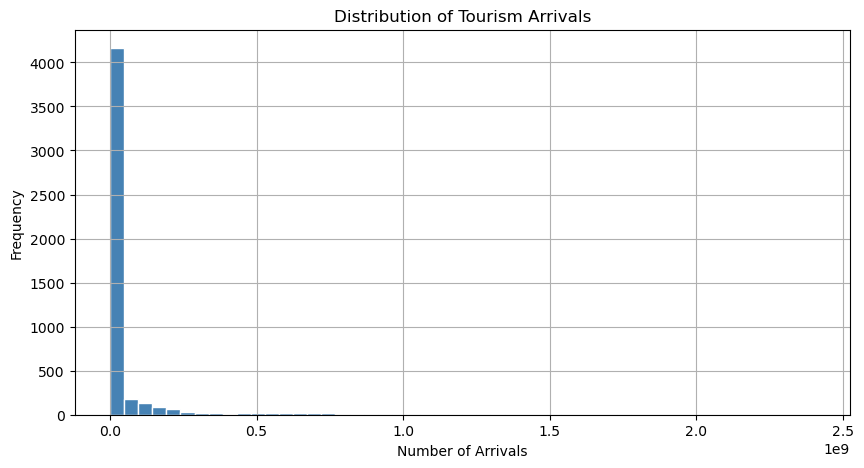

In [276]:
# Section 5 - Visualization 1: Histogram of Tourism Arrivals
plt.figure(figsize=(10,5))
plt.hist(df['tourism_arrivals'].dropna(), bins=50, color='steelblue', edgecolor='white')
plt.title("Distribution of Tourism Arrivals")
plt.xlabel("Number of Arrivals")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

### Visualization 2 - Box Plot: Tourism Receipts by Decade

**Columns used:** tourism_receipts, decade
**Why these columns:** To compare economic impact of tourism over time
**Why a box plot:** To show the spread and outliers in each decade
**What it shows:** Tourism receipts grew every decade. The 2010s 
had the most outliers — countries earning billions from tourism.
The 2020s show a drop due to COVID-19.

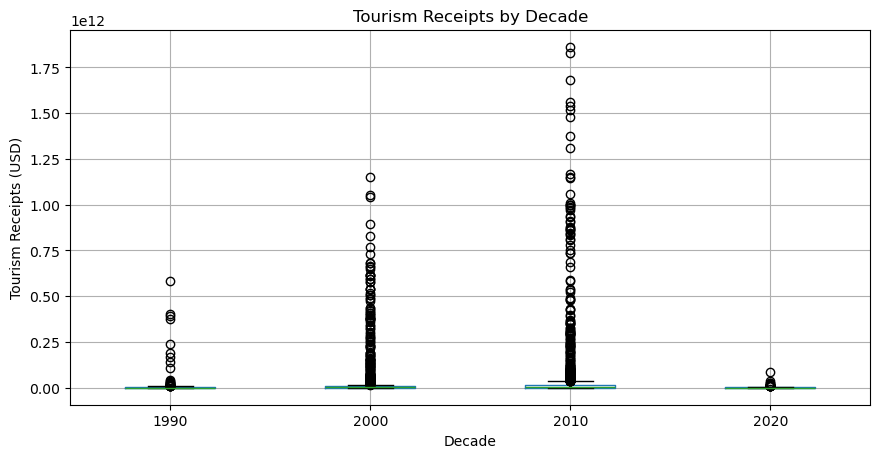

In [277]:
# Visualization 2: Box Plot of Tourism Receipts by decade
df['decade'] = (df['year'] // 10) * 10
df.boxplot(column='tourism_receipts', by='decade', figsize=(10,5))
plt.title("Tourism Receipts by Decade")
plt.suptitle("")
plt.xlabel("Decade")
plt.ylabel("Tourism Receipts (USD)")
plt.grid(True)
plt.show()

### Visualization 3 - Line Chart: Global Tourism Arrivals Over Time

- **Columns used:** year, tourism_arrivals
- **Why these columns:** To show the evolution of tourism over 25 years
- **Why a line chart:** A line chart is the best way to show trends 
  over time. It makes it easy to see growth and drops clearly.
- **What it shows:** Tourism grew consistently from 1999 to 2019. 
  In 2020, there was a dramatic drop due to COVID-19. 
  Recovery started in 2021 but is still below pre-pandemic levels.

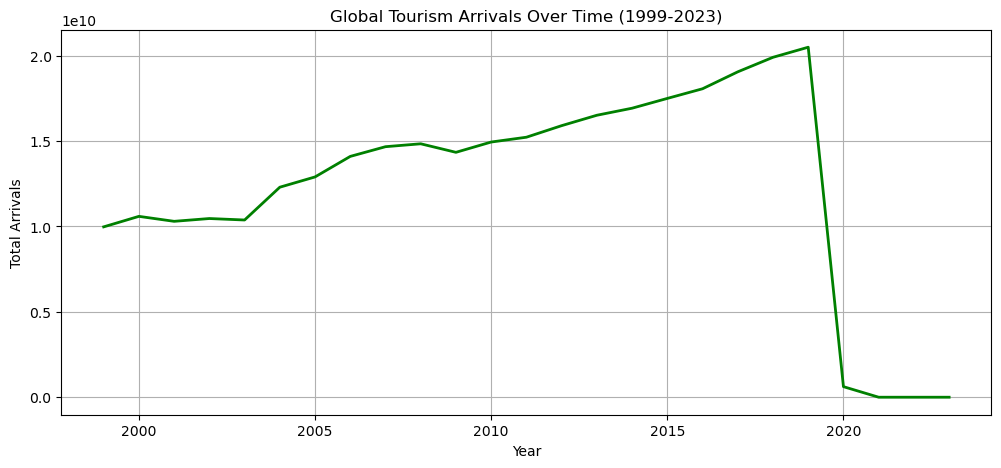

In [278]:
# Visualization 3: Global tourism arrivals over time
arrivals_by_year = df.groupby('year')['tourism_arrivals'].sum()

plt.figure(figsize=(12,5))
plt.plot(arrivals_by_year.index, arrivals_by_year.values, color='green', linewidth=2)
plt.title("Global Tourism Arrivals Over Time (1999-2023)")
plt.xlabel("Year")
plt.ylabel("Total Arrivals")
plt.grid(True)
plt.show()

## 6. Interpretation and Summary

Below is a summary of the main findings from this analysis.

In [279]:
# Section 6 - Summary
print("""
SUMMARY OF FINDINGS:

DATASET SELECTION:
I chose this dataset because tourism data reflects real world events.
With 25 years of data from 266 countries, it is possible to see how 
global crises affect people and economies.

CENTRAL TENDENCY:
The average number of tourist arrivals is 62.6 million, but the median 
is only 2.5 million. This big difference shows that a few large countries 
receive most of the tourists. Most countries receive very few visitors.

SPREAD:
The data is very spread out. The smallest value is 900 arrivals and the 
largest is 2.4 billion. This confirms that tourism is not equal around 
the world.

VISUALIZATIONS:
- The histogram shows that most countries receive few tourists
- The box plot shows that tourism receipts grew every decade until 2020
- The line chart shows a dramatic drop in 2020 because of COVID-19
- The bar chart shows that France is the most visited country

KEY INSIGHTS:
- COVID-19 caused the biggest drop in global tourism in 25 years
- Before COVID, tourism was growing every year from 1999 to 2019
- After COVID, recovery has been slow
- France leads global tourism because of its culture and infrastructure
- This project helped me understand how data can tell real stories
""")


SUMMARY OF FINDINGS:

DATASET SELECTION:
I chose this dataset because tourism data reflects real world events.
With 25 years of data from 266 countries, it is possible to see how 
global crises affect people and economies.

CENTRAL TENDENCY:
The average number of tourist arrivals is 62.6 million, but the median 
is only 2.5 million. This big difference shows that a few large countries 
receive most of the tourists. Most countries receive very few visitors.

SPREAD:
The data is very spread out. The smallest value is 900 arrivals and the 
largest is 2.4 billion. This confirms that tourism is not equal around 
the world.

VISUALIZATIONS:
- The histogram shows that most countries receive few tourists
- The box plot shows that tourism receipts grew every decade until 2020
- The line chart shows a dramatic drop in 2020 because of COVID-19
- The bar chart shows that France is the most visited country

KEY INSIGHTS:
- COVID-19 caused the biggest drop in global tourism in 25 years
- Before COV

## Curiosity

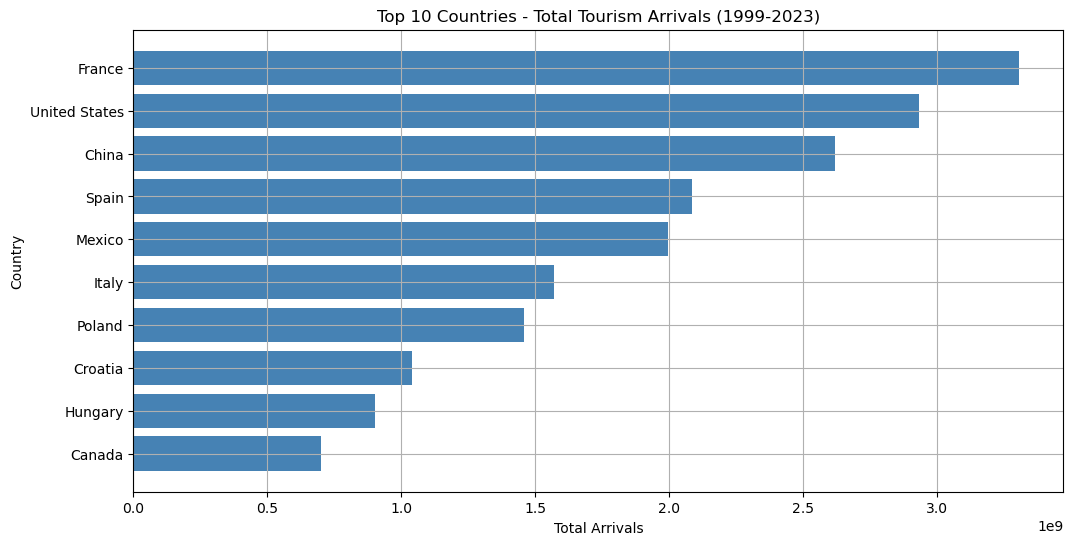

In [280]:
# Keep only specific real countries
keep = ['France', 'United States', 'China', 'Spain', 'Italy', 
        'Mexico', 'Turkey', 'Germany', 'United Kingdom', 'Greece',
        'Austria', 'Japan', 'Poland', 'Canada', 'Croatia',
        'Hungary', 'Portugal', 'Thailand', 'Netherlands', 'Brazil']

countries_only = df[df['country'].isin(keep)]

top_countries = countries_only.groupby('country')['tourism_arrivals'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.barh(top_countries.index, top_countries.values, color='steelblue')
plt.title("Top 10 Countries - Total Tourism Arrivals (1999-2023)")
plt.xlabel("Total Arrivals")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()